#Text Summarisation

Condense long text into its key points — two different ways.

Summarisation takes a long piece of text and produces a shorter version that preserves the
most important information. There are two fundamentally different approaches.

**Extractive vs. abstractive summarisation**

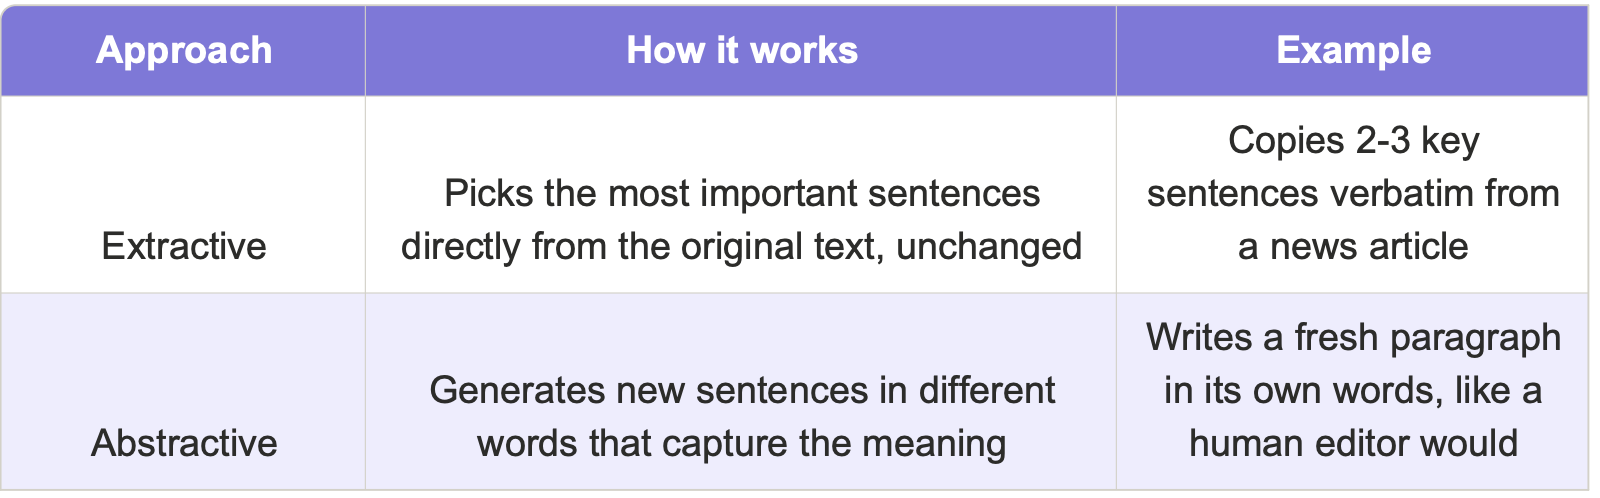

**Extractive summarisation — a simple approach**

Extractive methods often score sentences by importance (e.g. how many frequent/keyword
terms they contain) and select the top-scoring ones, keeping their original order.

In [ ]:
!pip install sumy

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 40.1 MB/s eta 0:00:00
  Created wheel for breadability: filename=breadability-0.1.20-py2.py3-none-any.whl size=21695 sha256=609c191a5b1d0a0c1c8dc2e531a2ba35b1a290e01a30b63484be5eb2889ce72d
  Stored in directory: /root/.cache/pip/wheels/32/99/64/59305409cacd03aa03e7bddf31a9db34b1fa7033bd41972662
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=75a002a24ab384493c4e1ef3870542d25b906517f5e26ebec14c5c8f5cd6a9df
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built breadability docopt


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.lsa import LsaSummarizer
text = """
 “Good morning. I am Rama Chandra, a Computer Science Engineering student with a strong interest in data-driven technologies. Over the last few months, I have focused on building my skills in Python, SQL, Machine Learning, and Data Analytics. I completed an AI/ML internship at SmartBridge where I worked on machine learning workflows including data preprocessing, model building, and evaluation. I have also completed certifications from IBM in Python and Java Fundamentals. I enjoy working on practical problems, learning new technologies, and continuously improving my technical abilities. I am currently looking for an opportunity to begin my professional journey and contribute effectively while growing as a technology professional.”
"""
parser = PlaintextParser.from_string(text, Tokenizer('english'))
summarizer = LsaSummarizer()
summary = summarizer(parser.document, 2) # pick top 2 sentences
for sentence in summary:
  print(sentence)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Over the last few months, I have focused on building my skills in Python, SQL, Machine Learning, and Data Analytics.
I enjoy working on practical problems, learning new technologies, and continuously improving my technical abilities.


**Abstractive summarisation with HuggingFace**

HuggingFace's transformers library provides ready-to-use pipelines for abstractive
summarisation, powered by pretrained models like BART or T5. One line of code is often
enough.

In [ ]:
!pip install transformers torch

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

article = """

“Good morning. I am Rama Chandra, a Computer Science Engineering student with a strong interest in data-driven technologies. Over the last few months, I have focused on building my skills in Python, SQL, Machine Learning, and Data Analytics. I completed an AI/ML internship at SmartBridge where I worked on machine learning workflows including data preprocessing, model building, and evaluation. I have also completed certifications from IBM in Python and Java Fundamentals. I enjoy working on practical problems, learning new technologies, and continuously improving my technical abilities. I am currently looking for an opportunity to begin my professional journey and contribute effectively while growing as a technology professional.”
"""

tokenizer = AutoTokenizer.from_pretrained("sshleifer/distilbart-cnn-12-6")
model = AutoModelForSeq2SeqLM.from_pretrained("sshleifer/distilbart-cnn-12-6")

inputs = tokenizer(article, return_tensors="pt", truncation=True, max_length=1024)
summary_ids = model.generate(inputs["input_ids"], num_beams=4, max_length=60, min_length=20, early_stopping=True)

print(tokenizer.decode(summary_ids[0], skip_special_tokens=True))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.80k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

 Rama Chandra is a Computer Science Engineering student with a strong interest in data-driven technologies . He is currently looking for an opportunity to begin his professional journey and contribute effectively .


input->encoder->learns meaning->decode->output sequnce

                Original Article

                       │
                       ▼

               AutoTokenizer

                       │
                       ▼

          Token IDs (input_ids tensor)

                       │
                       ▼

      DistilBART Seq2Seq Summarization Model

                       │
                       ▼

          Generated Summary Token IDs

                       │
                       ▼

             tokenizer.decode(...)

                       │
                       ▼
                       
          Human-readable text summary

Extractive vs abstractive — which to choose?

#Named Entity Recognition (NER)

Named Entity Recognition scans text and labels spans of words that refer to specific real-world
entities — people (PERSON), companies (ORG), places (LOC/GPE), dates (DATE), and
more.

Example:

Consider the sentence: "Elon Musk founded SpaceX in 2002 in Hawthorne." An NER model
would tag it like this:

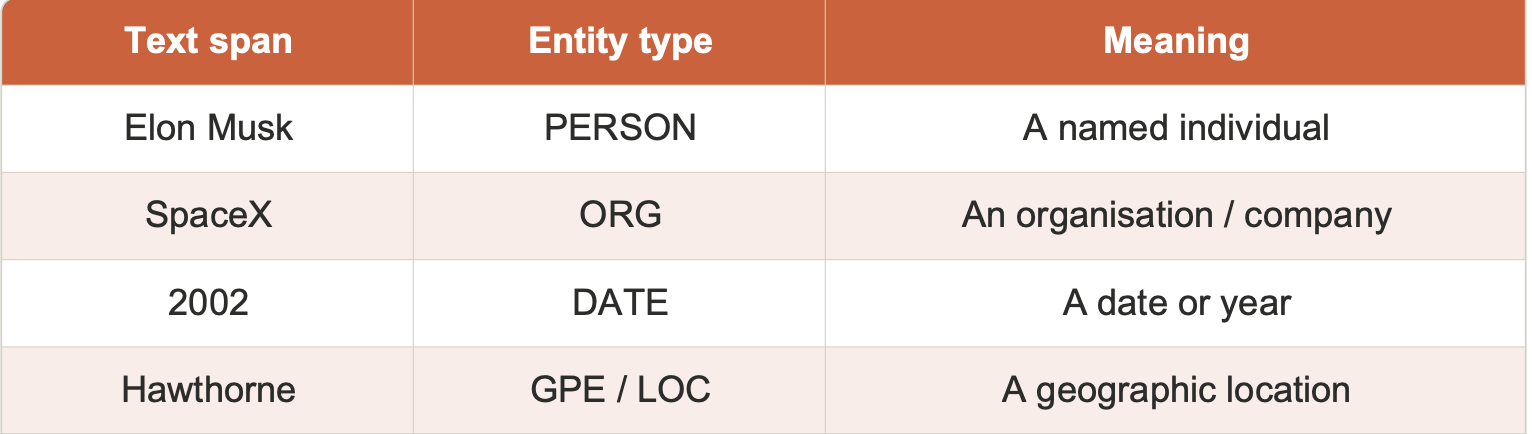

**NER with spaCy**

spaCy is a fast, production-ready NLP library with built-in NER models. It also provides a
built-in visualiser (displacy) that colour-codes entities directly in the text.

In [ ]:
!pip install spacy


In [ ]:
import spacy
nlp = spacy.load('en_core_web_sm')
text = 'the Vamsikumar went for a Secret Date with the special person from nen cheppani college but not ksrm Yesterday at NakNachina Restaurent'
doc = nlp(text)
for ent in doc.ents:
  print(ent.text, '->', ent.label_)

Vamsikumar -> PERSON
a Secret Date -> WORK_OF_ART
Yesterday -> DATE
NakNachina Restaurent -> ORG


**Colour-coded visualisation with displaCy**

In [ ]:
from spacy import displacy
# In a Jupyter notebook, this renders inline with coloured highlights:
displacy.render(doc, style='ent', jupyter=True)
# To save as an HTML file instead:
# Explicitly set jupyter=False to ensure displacy.render returns the HTML string
html = displacy.render(doc, style='ent', page=True, jupyter=False)
with open('entities.html', 'w') as f:
  f.write(html)

**Common spaCy entity labels**

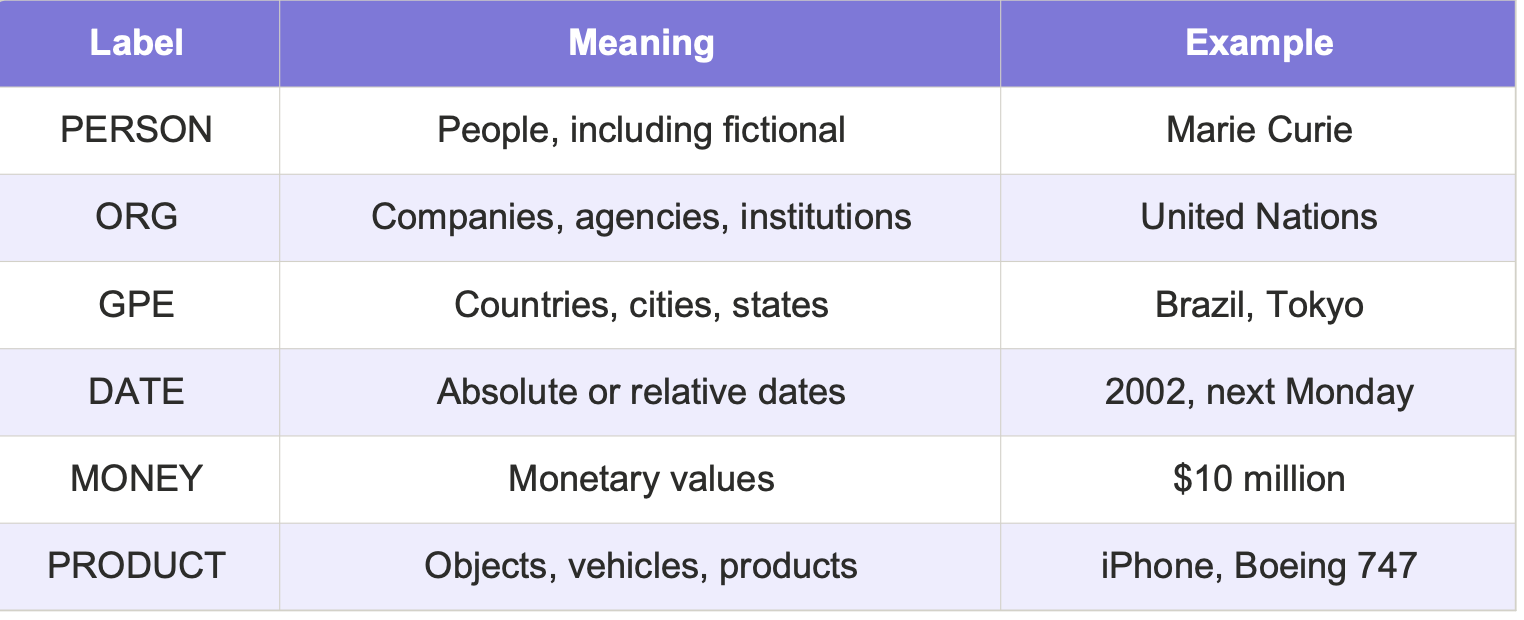

#Text Translation

From one-line English-to-French to 200+ language multilingual models.

Modern translation models can convert text between languages with near-human fluency,
accessible through HuggingFace pipelines in a single line of code.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# Load a specific translation model and tokenizer
tokenizer = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-hi")
model = AutoModelForSeq2SeqLM.from_pretrained("Helsinki-NLP/opus-mt-en-hi")

text_to_translate = 'Suma loves to eat in hostel for entire life'

# Tokenize the input text
inputs = tokenizer(text_to_translate, return_tensors="pt")

# Generate the translation
translated_ids = model.generate(**inputs)

# Decode the translated IDs back to text
translated_text = tokenizer.decode(translated_ids[0], skip_special_tokens=True)
print(translated_text)
# Expected Output: 'L'apprentissage automatique change le monde.'

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/812k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.10M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

सुता पूरे जीवन के लिए होस्टेल में खाने को प्यार करती है


**Multilingual models**

Some models — like Facebook's M2M-100 or NLLB (No Language Left Behind) — support
translating between 200+ languages with a single model, by specifying the source and target
language codes.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# A multilingual model that handles many language pairs
model_name = 'facebook/nllb-200-distilled-600M'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

text_to_translate = 'Good night, how are you?'
src_lang = 'eng_Latn'
tgt_lang = 'hin_Deva' # Hindi

# Set the source language for the tokenizer
tokenizer.src_lang = src_lang

# Tokenize the input text
inputs = tokenizer(text_to_translate, return_tensors="pt")

# Generate the translation, explicitly setting the target language
translated_ids = model.generate(**inputs, forced_bos_token_id=tokenizer.lang_code_to_id[tgt_lang])

# Decode the translated IDs back to text
translated_text = tokenizer.decode(translated_ids[0], skip_special_tokens=True)
print(translated_text)
# Expected Output (example for Hindi): 'सुप्रभात, आप कैसे हैं?'

config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/3.55k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

AttributeError: NllbTokenizer has no attribute lang_code_to_id

** **bold text**Building a simple multilingual FAQ bot**


Combine a small FAQ dictionary with a translation pipeline so users can ask questions and
receive answers in their preferred language.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# Load the multilingual model and tokenizer directly
model_name = 'facebook/nllb-200-distilled-600M'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

faq = {
'hours': 'We are open from 9 AM to 6 PM, Monday to Saturday.',
'returns': 'You can return any item within 30 days with a receipt.',
'shipping':'Standard shipping takes 3-5 business days.',
}

def answer_faq(question_key, target_lang_code):
  english_answer = faq.get(question_key, 'Sorry, I do not have that answer.')

  # Set the source language for the tokenizer
  tokenizer.src_lang = 'eng_Latn'

  # Tokenize the input text
  inputs = tokenizer(english_answer, return_tensors="pt")

  # Generate the translation, explicitly setting the target language
  translated_ids = model.generate(**inputs, forced_bos_token_id=tokenizer.convert_tokens_to_ids(target_lang_code))

  # Decode the translated IDs back to text
  translated_text = tokenizer.decode(translated_ids[0], skip_special_tokens=True)
  return translated_text

# Example: ask about shipping, answer in Spanish
print(answer_faq('hello', 'tel_Telu'))


#Lab — Build a News Digest Tool

Step 1 — Get sample articles

In [ ]:
articles = [
"""Apple unveiled its newest iPhone at an event in Cupertino on
Tuesday.
CEO Tim Cook said the device features a faster chip and improved
camera.
The phone will be available in stores starting next month, the company
said, with prices starting at $999.""",
"""The World Health Organization announced new guidelines on Monday
aimed at reducing sugar consumption worldwide. Officials in Geneva
said
the changes could prevent millions of cases of diabetes over the next
decade if adopted by national governments.""",
"""Tesla reported record deliveries for the third quarter, beating
analyst expectations. The Texas-based company said demand remained
strong in China and Europe despite increased competition from
traditional automakers entering the EV market.""",
"""NASA's Perseverance rover discovered new evidence of ancient
water activity on Mars, according to a paper published this week.
Scientists at the Jet Propulsion Laboratory said the findings
strengthen the case that the planet once had a wetter climate.""",
"""Manchester United announced the signing of a new midfielder
from Barcelona for a reported fee of 80 million euros. The 24-year-old
player will join the club ahead of the new season starting in
August.""",
]

Step 2 — Load models once

In [ ]:
import spacy
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# Load each model ONCE — reused for every article
nlp = spacy.load('en_core_web_sm')

# Direct loading for summarization model
summarizer_tokenizer = AutoTokenizer.from_pretrained("sshleifer/distilbart-cnn-12-6")
summarizer_model = AutoModelForSeq2SeqLM.from_pretrained("sshleifer/distilbart-cnn-12-6")

Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

Step 3 — Process each article

In [ ]:
def digest_article(text):
    # Summarise (abstractive, short)
    inputs = summarizer_tokenizer(text, return_tensors="pt", truncation=True, max_length=1024)
    summary_ids = summarizer_model.generate(inputs["input_ids"], num_beams=4, max_length=40, min_length=10, do_sample=False, early_stopping=True)
    summary_text = summarizer_tokenizer.decode(summary_ids[0], skip_special_tokens=True)

    # Extract entities
    doc = nlp(text)
    entities = {}

    for ent in doc.ents:
        entities.setdefault(ent.label_, set()).add(ent.text)

    return summary_text, entities


for i, article in enumerate(articles, 1):
    summary, entities = digest_article(article)

    print(f"--- Article {i} ---")
    print("Summary :", summary)
    print("Entities:")

    for label, names in entities.items():
        print(f"  {label}: {', '.join(names)}")

    print()

--- Article 1 ---
Summary :  CEO Tim Cook said the device features a faster chip and improved camera . The phone will be available in stores starting next month, with prices starting at $999 .
Entities:
  ORG: Apple
  GPE: Cupertino
  DATE: next month, Tuesday
  PERSON: Tim Cook
  MONEY: 999

--- Article 2 ---
Summary :  The World Health Organization announced new guidelines aimed at reducing sugar consumption worldwide . Officials in Geneva said the changes could prevent millions of cases of diabetes over the next decade .
Entities:
  ORG: The World Health Organization
  DATE: the next
decade, Monday
  GPE: Geneva
  CARDINAL: millions

--- Article 3 ---
Summary :  Tesla reported record deliveries for the third quarter, beating analyst expectations . The Texas-based company said demand remained strong in China and Europe .
Entities:
  DATE: the third quarter
  GPE: Texas, China
  LOC: Europe
  ORG: EV

--- Article 4 ---
Summary :  NASA's Perseverance rover discovered new evidence of an